In [1]:
import pandas as pd
import pickle
import torch
import numpy as np
from tqdm import tqdm
from sklearn.neighbors import KernelDensity as KDE

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
inf = pd.read_csv('../results/infectivity/2024-02-05/mutation_effects.csv')
neup = pd.read_csv('../results/neutralization/2024-01-19/mutation_effects_within_pools.csv')
neu = pd.read_csv('../results/neutralization/2024-01-19/mutation_effects_across_pools.csv')

In [3]:
with open('../model_infectivity/2024-02-05/mcmc_chain.pkl', 'rb') as p:
    inf_samples = pickle.load(p)
inf_data = torch.load('../model_infectivity/2024-02-05/mcmc_input_data.pt')
with open('../model_neutralization/2024-01-19/mcmc_chain.pkl', 'rb') as p:
    neu_samples = pickle.load(p)
neu_data = torch.load('../model_neutralization/2024-01-19/mcmc_input_data.pt')

In [4]:
print(inf_samples['σ_m'].mean())
inf[inf['Effect'].apply(lambda x: abs(x)) > inf_samples['σ_m'].mean().item()].sort_values(by='Effect', ascending=False)

tensor(0.4980)


,Mutation,Effect,N
0,S704L,1.156543,48.0
1,E484V,0.972844,30.0
2,V83A,0.947476,72.0
3,N501Y,0.745599,360.0
4,K356T,0.703990,24.0
5,P681H,0.639126,330.0
134,N439R,-0.556460,24.0
135,P681R,-0.564872,27.0
136,H655Y,-0.702046,354.0
137,S155R,-0.711008,55.0


In [5]:
inf_samples

{'b': tensor([ 0.0349, -0.0175, -0.0337,  ...,  0.0110,  0.0019,  0.0008]),
 'm': tensor([[-0.7014, -0.4513, -0.1761,  ..., -0.5271,  0.2998,  1.2852],
         [ 0.6282, -0.1980, -0.0797,  ...,  0.1469, -0.2352, -1.0160],
         [-0.3634, -0.2521, -0.1840,  ..., -0.6458,  0.1718,  1.2086],
         ...,
         [ 0.0775, -0.4108, -0.2134,  ..., -0.4245, -0.4740,  0.5516],
         [ 0.1502, -0.1164, -0.0127,  ...,  0.1101,  0.4804, -0.2702],
         [ 0.6943, -0.3786, -0.2091,  ..., -0.5803, -0.0125,  0.4615]]),
 'σ': tensor([0.1721, 0.1945, 0.1739,  ..., 0.1836, 0.1777, 0.1795]),
 'σ_b': tensor([9.4852e-02, 1.8326e+00, 2.3790e-01,  ..., 1.8297e-02, 2.4979e-01,
         8.8882e-04]),
 'σ_m': tensor([0.5416, 0.5341, 0.5316,  ..., 0.4671, 0.4467, 0.5550])}

In [6]:
muts = pd.DataFrame({'Mutation':inf_data['features'],
                     'Mean':inf_samples['m'].mean(dim=0),
                     'Std':inf_samples['m'].std(dim=0)})
muts['Factor'] = muts['Mean'] / muts['Std']
muts.sort_values(by='Factor', ascending=False)

,Mutation,Mean,Std,Factor
108,S704L,1.156543,0.145194,7.965486
12,E484V,0.972844,0.172950,5.625009
52,L452R,0.306965,0.060302,5.090480
90,R346T,0.178905,0.036956,4.841034
95,R683N,0.454697,0.100216,4.537169
...,...,...,...,...
61,N439R,-0.556460,0.097043,-5.734168
92,R403T,-1.349374,0.158824,-8.496035
98,S155R,-0.711008,0.079242,-8.972565
5,A701V,-1.043267,0.111194,-9.382439


In [7]:
muts = pd.DataFrame({'Mutation':inf_data['features'],
                     '5%':torch.quantile(inf_samples['m'], torch.tensor(0.05), dim=0),
                     '50%':torch.quantile(inf_samples['m'], torch.tensor(0.5), dim=0),
                     '95%':torch.quantile(inf_samples['m'], torch.tensor(0.95), dim=0)})
muts.sort_values(by='5%', ascending=False)

,Mutation,5%,50%,95%
108,S704L,0.912747,1.160611,1.382879
12,E484V,0.687624,0.972865,1.260648
128,V83A,0.342590,0.941773,1.557509
95,R683N,0.294396,0.454679,0.619618
41,K356T,0.291901,0.695086,1.128508
...,...,...,...,...
84,Q498Y,-1.071705,-0.494871,0.106452
78,P681R,-1.080772,-0.570082,-0.062487
5,A701V,-1.231238,-1.044525,-0.864205
92,R403T,-1.612063,-1.349155,-1.075494


In [8]:
sum(inf_samples['m'][:, inf_data['features'].index('Q498Y')]>0) / inf_samples['m'].shape[0]

tensor(0.0880)

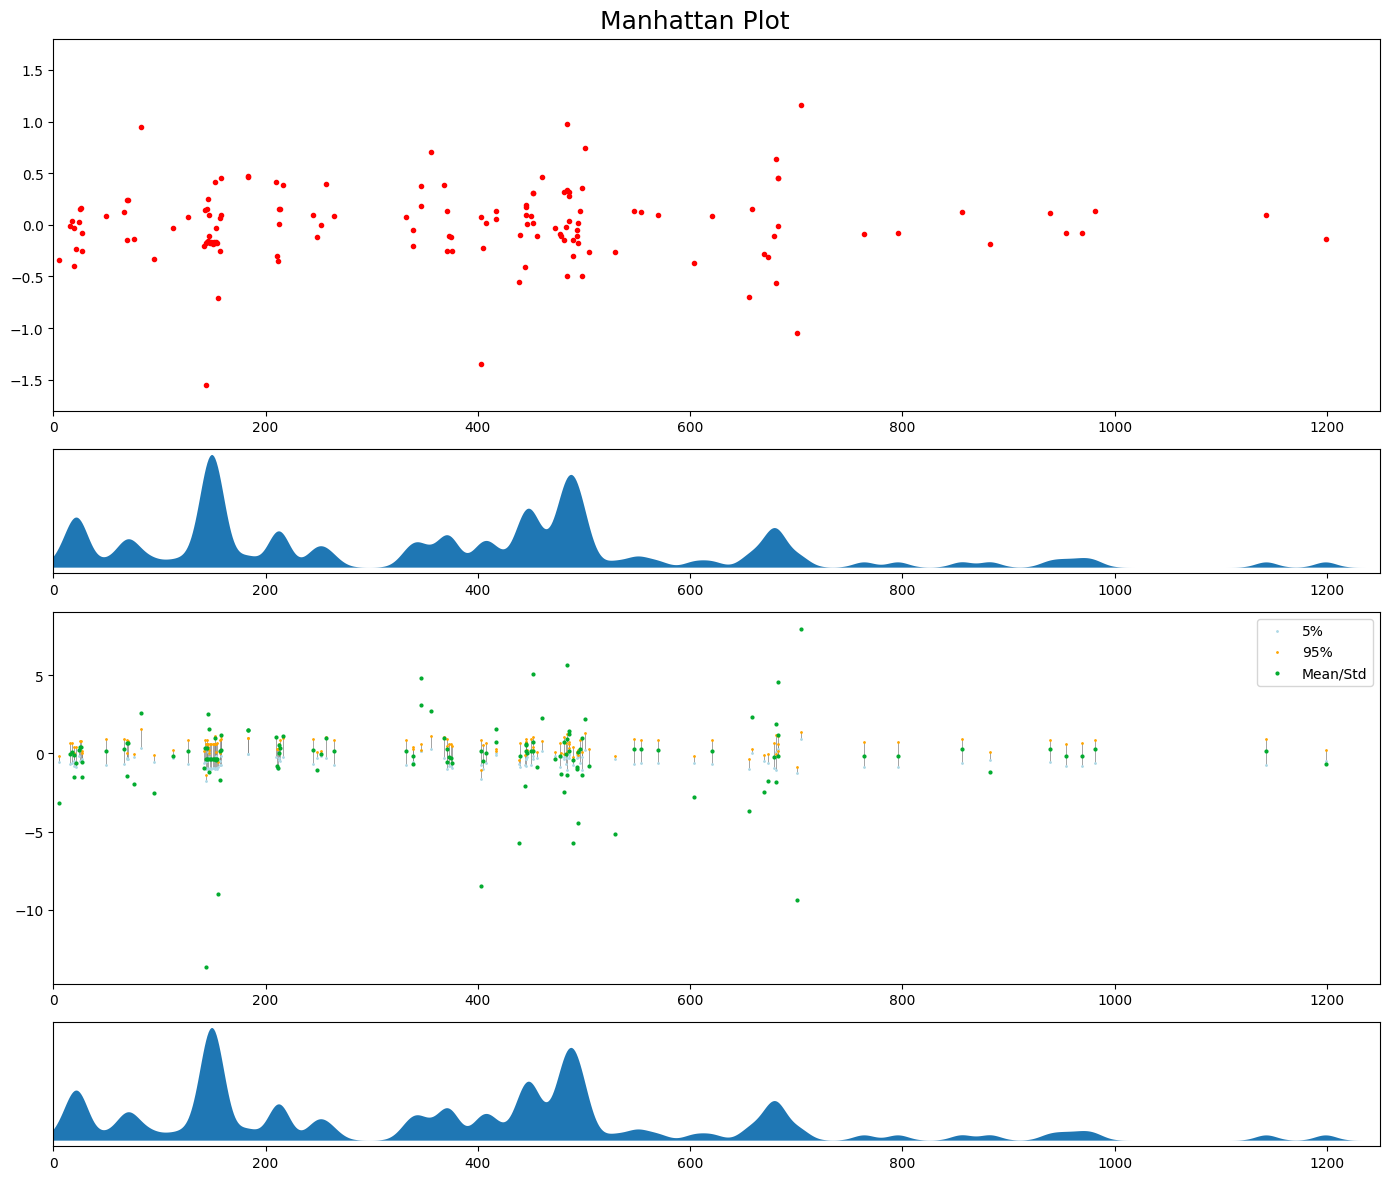

In [9]:
# Manhattan plot
def setup():
    fig, axes = plt.subplots(4,1, figsize=(14,12), gridspec_kw={'height_ratios': [4.5, 1.5, 4.5, 1.5]})
    
    options= dict()
    options['xlim'] = [0, 1250]
    options['ylim'] = [-1.8, 1.8]#[-1, 1]
    
    axes[0].set_xlim(options['xlim'])
    axes[0].set_ylim(options['ylim'])
    
    axes[1].set_xlim(options['xlim'])
    axes[1].set_yticks([])
    
    axes[2].set_xlim(options['xlim'])
    # axes[0].set_ylim(options['ylim'])
    
    axes[3].set_xlim(options['xlim'])
    axes[3].set_yticks([])
    
    return fig, axes, options

def preprocess_manhattan(samples, labels):
    means = samples.mean(dim=0)
    coefficients = labels.copy()
    
    positions = [int(''.join(filter(str.isdigit, c))) for c in coefficients] #[int(c[1:-1]) for c in coefficients]
    return means, positions, coefficients

def plot_coef(ax, means, positions, coefficients, options):
    ax.plot(positions, means, 'ro', markersize=3, label='Mean')
    
    # texts = []
    # for i, (pos, fea) in enumerate(zip(positions, coefficients)):
    #     x = pos
    #     y = means[i]
    #     text = fea #+ '\n' + '{:1.2f}'.format(y)
    #     texts.append(ax.annotate(text, xy=(x, y), xytext=(x, y), fontsize=8))

    # adjust_text(texts);
    
    ax.set_xlim(options['xlim'])
    
def plot_95(ax, samples, positions):
    width=1
    low = []
    high = []
    for i, p in enumerate(positions):
        y1 = torch.quantile(inf_samples['m'], torch.tensor(0.05), dim=0)[i]
        y2 = torch.quantile(inf_samples['m'], torch.tensor(0.95), dim=0)[i]
        ax.vlines([p], y1, y2, color='gray', linewidth=0.5)
        low += [y1]
        high += [y2]
    ax.plot(positions, low, 'o', color='lightblue', markersize=1, alpha=1, label='5%')
    ax.plot(positions, high, 'o', color='orange',    markersize=1, alpha=1, label='95%')
       
        
def plot_metric(ax, samples, positions):
    # ax = ax.twinx()
    metric = samples.mean(dim=0) / samples.std(dim=0)
    ax.plot(positions, metric, 'o', color='xkcd:kelly green', markersize=2, label='Mean/Std')
    
    
def plot_density(ax, positions, options):
    xlim = options['xlim']
    ylim = options['ylim']
    num_points=1000
    # Fit KDE
    kde = KDE(kernel='gaussian', bandwidth=10).fit(np.array(positions).reshape(-1,1))
    x = np.linspace(xlim[0], xlim[1], num_points).reshape(-1,1)
    # Generate KDE curve
    y = np.exp(kde.score_samples(x))
    
    ax.fill_between(x.flatten(), np.zeros_like(y), y)
    
    return kde


fig, axes, options = setup()
all_means, positions, coefficients = preprocess_manhattan(inf_samples['m'], inf_data['features'])
kde = plot_density(axes[1], positions, options)
plot_coef(axes[0], all_means, positions, coefficients, options)
kde = plot_density(axes[3], positions, options)
plot_95(axes[2], inf_samples['m'], positions)
plot_metric(axes[2], inf_samples['m'], positions)
axes[2].legend()
fig.suptitle('Manhattan Plot', fontsize=18)
fig.tight_layout()
# fig.savefig('figs/infectivity/Results/Manhattan.png', dpi=150)

In [15]:
neu_samples.keys()

dict_keys(['b', 'm0', 'mp', 'σ', 'σ_b', 'σ_m', 'σ_mp'])

In [20]:
print(neu_samples['σ_m'].mean())
neu[neu['Mean Effect'].apply(lambda x: abs(x)) > neu_samples['σ_m'].mean().item()].sort_values(by='Mean Effect')

tensor(0.3297)


,Mutation,Mean Effect,N
0,K444T,-0.656364,61.0
1,F486S,-0.625525,367.0
2,L452R,-0.578281,620.0
3,K417N,-0.526447,1295.0
4,F486P,-0.471236,19.0
5,S494R,-0.390986,257.0
6,K147N,-0.339669,339.0
109,S155R,0.437400,189.0


In [24]:
muts = pd.DataFrame({'Mutation':neu_data['features'],
                     'Mean':neu_samples['m0'].mean(dim=0),
                     'Std':neu_samples['m0'].std(dim=0)})
muts['Factor'] = muts['Mean'] / muts['Std']
muts.sort_values(by='Factor', ascending=True)

,Mutation,Mean,Std,Factor
48,L452R,-0.578281,0.108835,-5.313372
85,S494R,-0.390986,0.081171,-4.816803
76,R346T,-0.314283,0.083603,-3.759232
39,K444T,-0.656364,0.203037,-3.232731
19,F486S,-0.625525,0.210458,-2.972208
...,...,...,...,...
86,S704L,0.187463,0.205831,0.910762
27,G339H,0.245320,0.246352,0.995810
93,T478K,0.192458,0.162098,1.187300
38,K417V,0.227401,0.147126,1.545622


In [26]:
muts = pd.DataFrame({'Mutation':neu_data['features'],
                     '5%':torch.quantile(neu_samples['m0'], torch.tensor(0.05), dim=0),
                     '50%':torch.quantile(neu_samples['m0'], torch.tensor(0.5), dim=0),
                     '95%':torch.quantile(neu_samples['m0'], torch.tensor(0.95), dim=0)})
muts.sort_values(by='95%', ascending=True)

,Mutation,5%,50%,95%
48,L452R,-0.758162,-0.576823,-0.400166
39,K444T,-0.996668,-0.652425,-0.340149
19,F486S,-0.962149,-0.622442,-0.291669
85,S494R,-0.533155,-0.388906,-0.256792
36,K417N,-0.838314,-0.522175,-0.216301
...,...,...,...,...
29,G496S,-0.510110,0.004942,0.571091
94,T547K,-0.500128,0.023000,0.574658
107,Y145del,-0.585923,-0.000761,0.591541
79,S155R,0.221067,0.437207,0.641748
